In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
SID4 = 2122
SEED = SID4

HP_ID = SID4 % 6

print("SID4:", SID4)
print("SEED:", SEED)
print("HP_ID:", HP_ID)

SID4: 2122
SEED: 2122
HP_ID: 4


### Imports

In [2]:
import os
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import tensorflow as tf


### Reading the Dataset

In [3]:
# Path to the attached dataset
CSV_PATH = "/content/diabetes.csv"


col_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
             "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]


# The dataset has no header row
data = pd.read_csv(CSV_PATH, header=None, names=col_names)

In [4]:
print("Dataset shape:", data.shape)
print("\nFirst five rows:")
data.head()

Dataset shape: (759, 9)

First five rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


In [5]:
print("\nColumn data types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nClass distribution:")
print(data.iloc[:, -1].value_counts())


Column data types:
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Class distribution:
Outcome
1    496
0    263
Name: count, dtype: int64


In [6]:
# Assign readable column names
feature_names = [f"Feature_{i}" for i in range(1, 9)]
data.columns = feature_names + ["Target"]

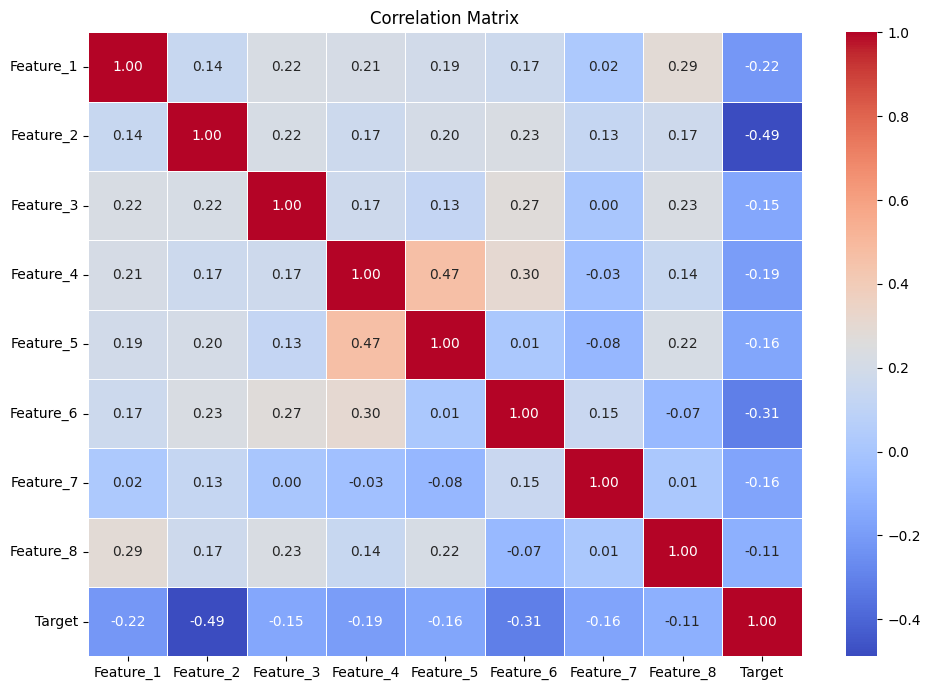

In [7]:
correlation = data.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

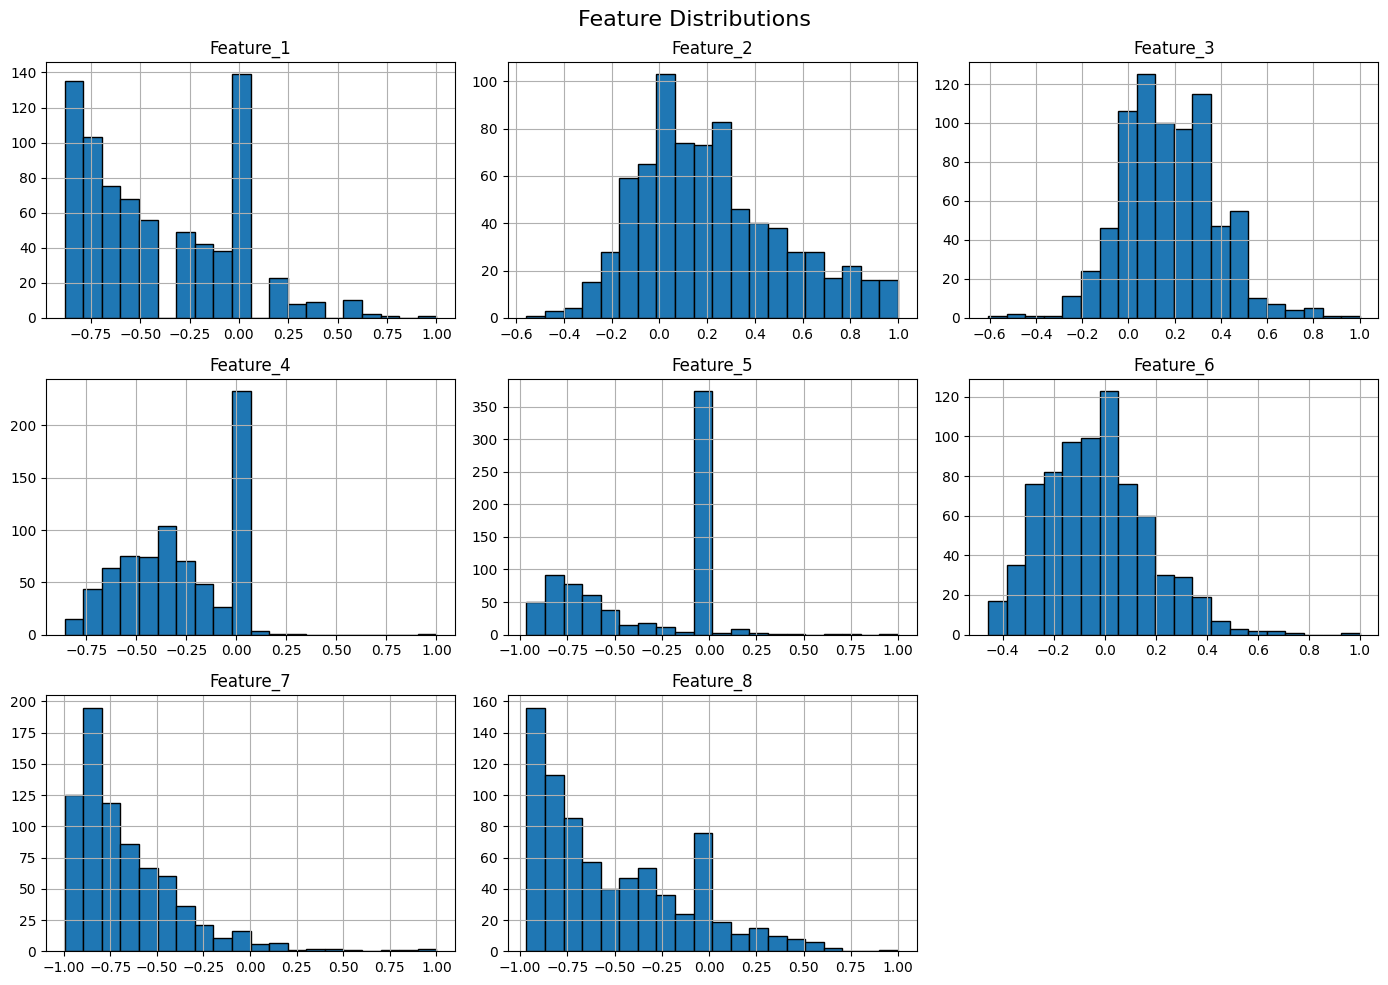

In [8]:
data[feature_names].hist(
    bins=20,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

### Splitting the dataset

In [9]:

# Separate features and target
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Split temporary data into 15% validation and 15% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)


In [10]:
X_train.shape, X_temp.shape, y_train.shape, y_temp.shape

((531, 8), (228, 8), (531,), (228,))

In [11]:
X_val.shape, X_test.shape, y_val.shape, y_test.shape

((114, 8), (114, 8), (114,), (114,))

### Standardizing the data

In [12]:
# Standardize using only the training data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

Training set: (531, 8)
Validation set: (114, 8)
Testing set: (114, 8)


### Defining Model Configurations for baseline and Modified models

In [13]:
baseline_config = {
    "hidden_layers": [64, 32],
    "learning_rate": 0.001,
    "epochs": 30
}

# HP_ID is already defined in the first cell
if HP_ID == 4:
    modified_config = {
        "hidden_layers": [64, 32],
        "learning_rate": 0.001,
        "epochs": 15
    }

print("Baseline configuration:")
print(baseline_config)

print("\nModified configuration:")
print("HP_ID:", HP_ID)
print(modified_config)

Baseline configuration:
{'hidden_layers': [64, 32], 'learning_rate': 0.001, 'epochs': 30}

Modified configuration:
HP_ID: 4
{'hidden_layers': [64, 32], 'learning_rate': 0.001, 'epochs': 15}


### **Model Training using Pytorch**

In [14]:
# Convert NumPy arrays into PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# Create a training DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

print("PyTorch tensors created successfully.")
print("Training features shape:", X_train_tensor.shape)
print("Training labels shape:", y_train_tensor.shape)

PyTorch tensors created successfully.
Training features shape: torch.Size([531, 8])
Training labels shape: torch.Size([531, 1])


In [15]:
class DiabetesNetwork(nn.Module):
    def __init__(self, input_size, hidden_layers):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(nn.ReLU())
            previous_size = hidden_size

        # One output neuron for binary classification
        layers.append(nn.Linear(previous_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Create the baseline PyTorch model
baseline_model = DiabetesNetwork(
    input_size=X_train.shape[1],
    hidden_layers=baseline_config["hidden_layers"]
)

# Create the modified PyTorch model
modified_model = DiabetesNetwork(
    input_size=X_train.shape[1],
    hidden_layers=modified_config["hidden_layers"]
)

print("Baseline model:")
print(baseline_model)

print("\nModified model:")
print(modified_model)

Baseline model:
DiabetesNetwork(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Modified model:
DiabetesNetwork(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Baseline Model Training

In [16]:
# Use the same loss function for both frameworks
loss_function = nn.BCEWithLogitsLoss()

# Optimizer for the baseline model
baseline_optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=baseline_config["learning_rate"]
)

baseline_train_losses = []
baseline_validation_losses = []

for epoch in range(baseline_config["epochs"]):
    # Training mode
    baseline_model.train()
    total_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        baseline_optimizer.zero_grad()

        predictions = baseline_model(batch_X)
        loss = loss_function(predictions, batch_y)

        loss.backward()
        baseline_optimizer.step()

        total_train_loss += loss.item() * batch_X.size(0)

    average_train_loss = total_train_loss / len(train_loader.dataset)

    # Validation mode
    baseline_model.eval()

    with torch.no_grad():
        validation_predictions = baseline_model(X_val_tensor)
        validation_loss = loss_function(
            validation_predictions,
            y_val_tensor
        ).item()

    baseline_train_losses.append(average_train_loss)
    baseline_validation_losses.append(validation_loss)

    print(
        f"Epoch [{epoch + 1}/{baseline_config['epochs']}], "
        f"Training Loss: {average_train_loss:.4f}, "
        f"Validation Loss: {validation_loss:.4f}"
    )

Epoch [1/30], Training Loss: 0.6425, Validation Loss: 0.6034
Epoch [2/30], Training Loss: 0.5845, Validation Loss: 0.5469
Epoch [3/30], Training Loss: 0.5389, Validation Loss: 0.5053
Epoch [4/30], Training Loss: 0.5065, Validation Loss: 0.4782
Epoch [5/30], Training Loss: 0.4887, Validation Loss: 0.4587
Epoch [6/30], Training Loss: 0.4774, Validation Loss: 0.4454
Epoch [7/30], Training Loss: 0.4693, Validation Loss: 0.4440
Epoch [8/30], Training Loss: 0.4644, Validation Loss: 0.4401
Epoch [9/30], Training Loss: 0.4597, Validation Loss: 0.4407
Epoch [10/30], Training Loss: 0.4562, Validation Loss: 0.4372
Epoch [11/30], Training Loss: 0.4520, Validation Loss: 0.4402
Epoch [12/30], Training Loss: 0.4483, Validation Loss: 0.4420
Epoch [13/30], Training Loss: 0.4456, Validation Loss: 0.4416
Epoch [14/30], Training Loss: 0.4441, Validation Loss: 0.4370
Epoch [15/30], Training Loss: 0.4392, Validation Loss: 0.4417
Epoch [16/30], Training Loss: 0.4364, Validation Loss: 0.4383
Epoch [17/30], Tr

### Modified Model Training

In [17]:
# Optimizer for the modified model
modified_optimizer = optim.Adam(
    modified_model.parameters(),
    lr=modified_config["learning_rate"]
)

modified_train_losses = []
modified_validation_losses = []

for epoch in range(modified_config["epochs"]):
    # Training mode
    modified_model.train()
    total_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        modified_optimizer.zero_grad()

        predictions = modified_model(batch_X)
        loss = loss_function(predictions, batch_y)

        loss.backward()
        modified_optimizer.step()

        total_train_loss += loss.item() * batch_X.size(0)

    average_train_loss = total_train_loss / len(train_loader.dataset)

    # Validation mode
    modified_model.eval()

    with torch.no_grad():
        validation_predictions = modified_model(X_val_tensor)
        validation_loss = loss_function(
            validation_predictions,
            y_val_tensor
        ).item()

    modified_train_losses.append(average_train_loss)
    modified_validation_losses.append(validation_loss)

    print(
        f"Epoch [{epoch + 1}/{modified_config['epochs']}], "
        f"Training Loss: {average_train_loss:.4f}, "
        f"Validation Loss: {validation_loss:.4f}"
    )

Epoch [1/15], Training Loss: 0.6912, Validation Loss: 0.6479
Epoch [2/15], Training Loss: 0.6215, Validation Loss: 0.5828
Epoch [3/15], Training Loss: 0.5636, Validation Loss: 0.5337
Epoch [4/15], Training Loss: 0.5236, Validation Loss: 0.4915
Epoch [5/15], Training Loss: 0.4943, Validation Loss: 0.4646
Epoch [6/15], Training Loss: 0.4812, Validation Loss: 0.4497
Epoch [7/15], Training Loss: 0.4711, Validation Loss: 0.4442
Epoch [8/15], Training Loss: 0.4663, Validation Loss: 0.4417
Epoch [9/15], Training Loss: 0.4620, Validation Loss: 0.4352
Epoch [10/15], Training Loss: 0.4576, Validation Loss: 0.4401
Epoch [11/15], Training Loss: 0.4536, Validation Loss: 0.4362
Epoch [12/15], Training Loss: 0.4513, Validation Loss: 0.4351
Epoch [13/15], Training Loss: 0.4461, Validation Loss: 0.4395
Epoch [14/15], Training Loss: 0.4438, Validation Loss: 0.4390
Epoch [15/15], Training Loss: 0.4396, Validation Loss: 0.4395


In [18]:
def calculate_accuracy(model, X_data, y_data):
    model.eval()

    with torch.no_grad():
        logits = model(X_data)

        # Convert logits into probabilities
        probabilities = torch.sigmoid(logits)

        # Convert probabilities into class predictions
        predictions = (probabilities >= 0.5).float()

        correct_predictions = (predictions == y_data).sum().item()
        total_predictions = y_data.size(0)

    return correct_predictions / total_predictions


baseline_test_accuracy = calculate_accuracy(
    baseline_model,
    X_test_tensor,
    y_test_tensor
)

modified_test_accuracy = calculate_accuracy(
    modified_model,
    X_test_tensor,
    y_test_tensor
)

print(f"Baseline PyTorch test accuracy: "
      f"{baseline_test_accuracy:.4f}")

print(f"Modified PyTorch test accuracy: "
      f"{modified_test_accuracy:.4f}")

Baseline PyTorch test accuracy: 0.7982
Modified PyTorch test accuracy: 0.7544


### **Model Training using Tensorflow**

In [21]:
# Set the TensorFlow random seed
tf.random.set_seed(SEED)

# Convert the data to TensorFlow tensors
X_train_tf = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

X_val_tf = tf.convert_to_tensor(X_val, dtype=tf.float32)
y_val_tf = tf.convert_to_tensor(y_val, dtype=tf.float32)

X_test_tf = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)

# Create a TensorFlow training dataset
train_dataset_tf = tf.data.Dataset.from_tensor_slices(
    (X_train_tf, y_train_tf)
)

train_dataset_tf = train_dataset_tf.shuffle(
    buffer_size=len(X_train),
    seed=SEED,
    reshuffle_each_iteration=True
).batch(32)

print("TensorFlow data prepared successfully.")
print("Training features shape:", X_train_tf.shape)
print("Training labels shape:", y_train_tf.shape)

TensorFlow data prepared successfully.
Training features shape: (531, 8)
Training labels shape: (531,)


In [22]:
def create_tensorflow_model(hidden_layers):
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

    # Hidden layers
    for neurons in hidden_layers:
        model.add(
            tf.keras.layers.Dense(
                neurons,
                activation="relu"
            )
        )

    # Output layer for binary classification
    model.add(tf.keras.layers.Dense(1))

    return model


# Create the TensorFlow baseline model
baseline_tf_model = create_tensorflow_model(
    baseline_config["hidden_layers"]
)

# Create the TensorFlow modified model
modified_tf_model = create_tensorflow_model(
    modified_config["hidden_layers"]
)

print("TensorFlow baseline model:")
baseline_tf_model.summary()

print("\nTensorFlow modified model:")
modified_tf_model.summary()

TensorFlow baseline model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compile the baseline TensorFlow model
baseline_tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=baseline_config["learning_rate"]
    ),
    loss=tf.keras.losses.BinaryCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

# Compile the modified TensorFlow model
modified_tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=modified_config["learning_rate"]
    ),
    loss=tf.keras.losses.BinaryCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

print("Both TensorFlow models compiled successfully.")

Both TensorFlow models compiled successfully.


### Baseline Model Training

In [24]:
baseline_tf_history = baseline_tf_model.fit(
    X_train_tf,
    y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=baseline_config["epochs"],
    batch_size=32,
    verbose=1
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 292ms/step - accuracy: 0.4689 - loss: 0.6459 - val_accuracy: 0.6491 - val_loss: 0.5841
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6535 - loss: 0.5719 - val_accuracy: 0.7807 - val_loss: 0.5206
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7250 - loss: 0.5265 - val_accuracy: 0.7719 - val_loss: 0.4818
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7458 - loss: 0.4971 - val_accuracy: 0.8158 - val_loss: 0.4591
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7552 - loss: 0.4782 - val_accuracy: 0.8246 - val_loss: 0.4475
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7589 - loss: 0.4656 - val_accuracy: 0.7895 - val_loss: 0.4426
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7665 - loss: 0.4568 - val_accuracy: 0.7895 - val_loss: 0.4413
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7740 - loss: 0.4501 - val_accuracy: 0.7895 - 

### Modified Model Training

In [25]:
modified_tf_history = modified_tf_model.fit(
    X_train_tf,
    y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=modified_config["epochs"],
    batch_size=32,
    verbose=1
)

Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5330 - loss: 0.6206 - val_accuracy: 0.6404 - val_loss: 0.5759
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6949 - loss: 0.5619 - val_accuracy: 0.7456 - val_loss: 0.5294
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7345 - loss: 0.5258 - val_accuracy: 0.7982 - val_loss: 0.4989
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7439 - loss: 0.5010 - val_accuracy: 0.7982 - val_loss: 0.4788
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7495 - loss: 0.4845 - val_accuracy: 0.7982 - val_loss: 0.4641
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7514 - loss: 0.4730 - val_accuracy: 0.7982 - val_loss: 0.4539
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7589 - loss: 0.4649 - val_accuracy: 0.7982 - val_loss: 0.4481
Epoch 8/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7665 - loss: 0.4585 - val_accuracy: 0.8070 - val

## **Final Analysis**

In [28]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)


def run_pytorch_model(config, seed):
    set_seed(seed)

    model = DiabetesNetwork(
        input_size=X_train.shape[1],
        hidden_layers=config["hidden_layers"]
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=config["learning_rate"]
    )

    for epoch in range(config["epochs"]):
        model.train()

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            predictions = model(batch_X)
            loss = loss_function(predictions, batch_y)

            loss.backward()
            optimizer.step()

    return calculate_accuracy(
        model,
        X_test_tensor,
        y_test_tensor
    )


training_seeds = [SEED, SEED + 1, SEED + 2]

baseline_pytorch_accuracies = []
modified_pytorch_accuracies = []

for seed in training_seeds:
    baseline_accuracy = run_pytorch_model(
        baseline_config,
        seed
    )

    modified_accuracy = run_pytorch_model(
        modified_config,
        seed
    )

    baseline_pytorch_accuracies.append(baseline_accuracy)
    modified_pytorch_accuracies.append(modified_accuracy)

print("Baseline PyTorch accuracies:")
print(baseline_pytorch_accuracies)

print("Modified PyTorch accuracies:")
print(modified_pytorch_accuracies)

print("\nBaseline PyTorch mean:",
      np.mean(baseline_pytorch_accuracies))

print("Baseline PyTorch standard deviation:",
      np.std(baseline_pytorch_accuracies, ddof=1))

print("\nModified PyTorch mean:",
      np.mean(modified_pytorch_accuracies))

print("Modified PyTorch standard deviation:",
      np.std(modified_pytorch_accuracies, ddof=1))

Baseline PyTorch accuracies:
[0.7894736842105263, 0.7807017543859649, 0.7807017543859649]
Modified PyTorch accuracies:
[0.7631578947368421, 0.7719298245614035, 0.7719298245614035]

Baseline PyTorch mean: 0.7836257309941521
Baseline PyTorch standard deviation: 0.005064476045523049

Modified PyTorch mean: 0.7690058479532164
Modified PyTorch standard deviation: 0.005064476045522985


In [26]:
# Evaluate the baseline model
baseline_tf_results = baseline_tf_model.evaluate(
    X_test_tf,
    y_test_tf,
    verbose=0
)

# Evaluate the modified model
modified_tf_results = modified_tf_model.evaluate(
    X_test_tf,
    y_test_tf,
    verbose=0
)

# The second value is accuracy because metrics=["accuracy"]
baseline_tf_test_accuracy = baseline_tf_results[1]
modified_tf_test_accuracy = modified_tf_results[1]

print(f"Baseline TensorFlow test accuracy: "
      f"{baseline_tf_test_accuracy:.4f}")

print(f"Modified TensorFlow test accuracy: "
      f"{modified_tf_test_accuracy:.4f}")

Baseline TensorFlow test accuracy: 0.7368
Modified TensorFlow test accuracy: 0.7368


In [29]:
def run_tensorflow_model(config, seed):
    # Set the TensorFlow seed
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = create_tensorflow_model(
        config["hidden_layers"]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        ),
        loss=tf.keras.losses.BinaryCrossentropy(
            from_logits=True
        ),
        metrics=["accuracy"]
    )

    model.fit(
        X_train_tf,
        y_train_tf,
        validation_data=(X_val_tf, y_val_tf),
        epochs=config["epochs"],
        batch_size=32,
        verbose=0,
        shuffle=True
    )

    results = model.evaluate(
        X_test_tf,
        y_test_tf,
        verbose=0
    )

    return results[1]


baseline_tensorflow_accuracies = []
modified_tensorflow_accuracies = []

for seed in training_seeds:
    baseline_accuracy = run_tensorflow_model(
        baseline_config,
        seed
    )

    modified_accuracy = run_tensorflow_model(
        modified_config,
        seed
    )

    baseline_tensorflow_accuracies.append(baseline_accuracy)
    modified_tensorflow_accuracies.append(modified_accuracy)

print("Baseline TensorFlow accuracies:")
print(baseline_tensorflow_accuracies)

print("Modified TensorFlow accuracies:")
print(modified_tensorflow_accuracies)

print("\nBaseline TensorFlow mean:",
      np.mean(baseline_tensorflow_accuracies))

print("Baseline TensorFlow standard deviation:",
      np.std(baseline_tensorflow_accuracies, ddof=1))

print("\nModified TensorFlow mean:",
      np.mean(modified_tensorflow_accuracies))

print("Modified TensorFlow standard deviation:",
      np.std(modified_tensorflow_accuracies, ddof=1))

Baseline TensorFlow accuracies:
[0.780701756477356, 0.7719298005104065, 0.7719298005104065]
Modified TensorFlow accuracies:
[0.7456140518188477, 0.7368420958518982, 0.7631579041481018]

Baseline TensorFlow mean: 0.774853785832723
Baseline TensorFlow standard deviation: 0.005064491138837816

Modified TensorFlow mean: 0.7485380172729492
Modified TensorFlow standard deviation: 0.013399351553460311


In [30]:
results_table = pd.DataFrame({
    "Framework": [
        "PyTorch",
        "PyTorch",
        "TensorFlow",
        "TensorFlow"
    ],
    "Model": [
        "Baseline",
        "Modified HP_ID 4",
        "Baseline",
        "Modified HP_ID 4"
    ],
    "Mean Test Accuracy": [
        np.mean(baseline_pytorch_accuracies),
        np.mean(modified_pytorch_accuracies),
        np.mean(baseline_tensorflow_accuracies),
        np.mean(modified_tensorflow_accuracies)
    ],
    "Standard Deviation": [
        np.std(baseline_pytorch_accuracies, ddof=1),
        np.std(modified_pytorch_accuracies, ddof=1),
        np.std(baseline_tensorflow_accuracies, ddof=1),
        np.std(modified_tensorflow_accuracies, ddof=1)
    ]
})

# Display percentages instead of decimal values
results_table["Mean Test Accuracy"] *= 100
results_table["Standard Deviation"] *= 100

print(results_table.to_string(index=False))

 Framework            Model  Mean Test Accuracy  Standard Deviation
   PyTorch         Baseline           78.362573            0.506448
   PyTorch Modified HP_ID 4           76.900585            0.506448
TensorFlow         Baseline           77.485379            0.506449
TensorFlow Modified HP_ID 4           74.853802            1.339935


In [31]:
accuracy_table = pd.DataFrame({
    "Framework": [
        "PyTorch",
        "PyTorch",
        "TensorFlow",
        "TensorFlow"
    ],
    "Model": [
        "Baseline",
        "Modified",
        "Baseline",
        "Modified"
    ],
    "Seed 2122": [
        baseline_pytorch_accuracies[0],
        modified_pytorch_accuracies[0],
        baseline_tensorflow_accuracies[0],
        modified_tensorflow_accuracies[0]
    ],
    "Seed 2123": [
        baseline_pytorch_accuracies[1],
        modified_pytorch_accuracies[1],
        baseline_tensorflow_accuracies[1],
        modified_tensorflow_accuracies[1]
    ],
    "Seed 2124": [
        baseline_pytorch_accuracies[2],
        modified_pytorch_accuracies[2],
        baseline_tensorflow_accuracies[2],
        modified_tensorflow_accuracies[2]
    ],
    "Mean Test Accuracy": [
        np.mean(baseline_pytorch_accuracies),
        np.mean(modified_pytorch_accuracies),
        np.mean(baseline_tensorflow_accuracies),
        np.mean(modified_tensorflow_accuracies)
    ],
    "Standard Deviation": [
        np.std(baseline_pytorch_accuracies, ddof=1),
        np.std(modified_pytorch_accuracies, ddof=1),
        np.std(baseline_tensorflow_accuracies, ddof=1),
        np.std(modified_tensorflow_accuracies, ddof=1)
    ]
})

# Convert accuracy values to percentages
accuracy_columns = [
    "Seed 2122",
    "Seed 2123",
    "Seed 2124",
    "Mean Test Accuracy",
    "Standard Deviation"
]

accuracy_table[accuracy_columns] *= 100

accuracy_table.round(2)

,Framework,Model,Seed 2122,Seed 2123,Seed 2124,Mean Test Accuracy,Standard Deviation
0,PyTorch,Baseline,78.95,78.07,78.07,78.36,0.51
1,PyTorch,Modified,76.32,77.19,77.19,76.90,0.51
2,TensorFlow,Baseline,78.07,77.19,77.19,77.49,0.51
3,TensorFlow,Modified,74.56,73.68,76.32,74.85,1.34


### **Pytorch Losses**

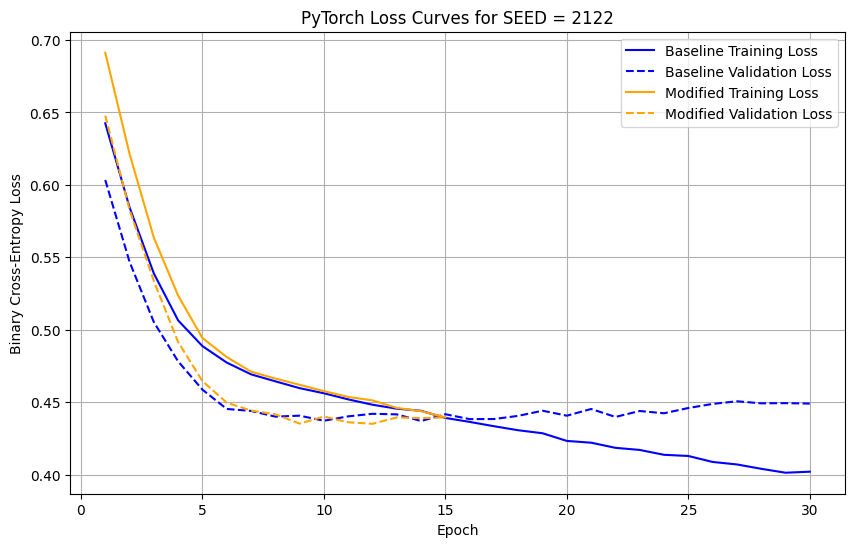

In [32]:
import matplotlib.pyplot as plt

baseline_epochs = range(1, len(baseline_train_losses) + 1)
modified_epochs = range(1, len(modified_train_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    baseline_epochs,
    baseline_train_losses,
    label="Baseline Training Loss",
    color="blue"
)

plt.plot(
    baseline_epochs,
    baseline_validation_losses,
    label="Baseline Validation Loss",
    color="blue",
    linestyle="--"
)

plt.plot(
    modified_epochs,
    modified_train_losses,
    label="Modified Training Loss",
    color="orange"
)

plt.plot(
    modified_epochs,
    modified_validation_losses,
    label="Modified Validation Loss",
    color="orange",
    linestyle="--"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title(f"PyTorch Loss Curves for SEED = {SEED}")
plt.legend()
plt.grid(True)
plt.show()

### **TensorFlow Losses**

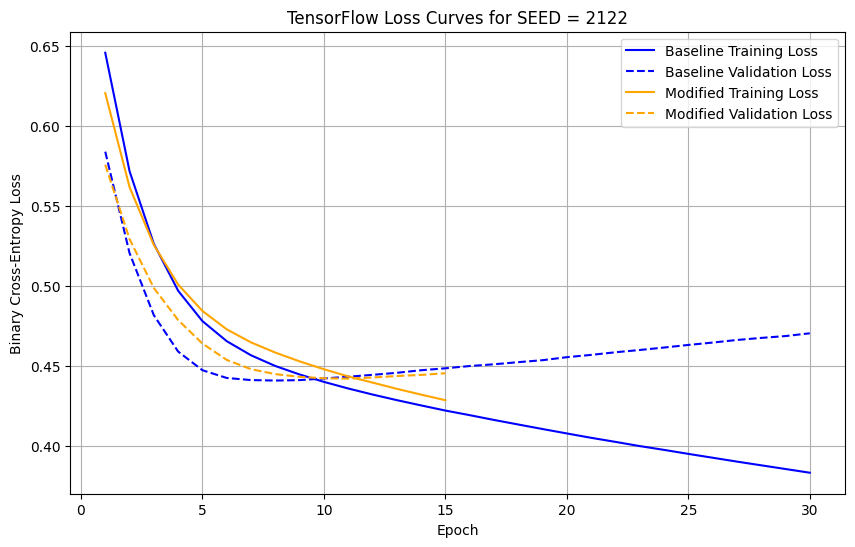

In [33]:
baseline_tf_epochs = range(
    1,
    len(baseline_tf_history.history["loss"]) + 1
)

modified_tf_epochs = range(
    1,
    len(modified_tf_history.history["loss"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    baseline_tf_epochs,
    baseline_tf_history.history["loss"],
    label="Baseline Training Loss",
    color="blue"
)

plt.plot(
    baseline_tf_epochs,
    baseline_tf_history.history["val_loss"],
    label="Baseline Validation Loss",
    color="blue",
    linestyle="--"
)

plt.plot(
    modified_tf_epochs,
    modified_tf_history.history["loss"],
    label="Modified Training Loss",
    color="orange"
)

plt.plot(
    modified_tf_epochs,
    modified_tf_history.history["val_loss"],
    label="Modified Validation Loss",
    color="orange",
    linestyle="--"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title(f"TensorFlow Loss Curves for SEED = {SEED}")
plt.legend()
plt.grid(True)
plt.show()

### **Identify the best validation-loss epoch**

In [34]:
# Find the epoch with the lowest validation loss

best_baseline_torch_epoch = (
    np.argmin(baseline_validation_losses) + 1
)

best_modified_torch_epoch = (
    np.argmin(modified_validation_losses) + 1
)

best_baseline_tf_epoch = (
    np.argmin(baseline_tf_history.history["val_loss"]) + 1
)

best_modified_tf_epoch = (
    np.argmin(modified_tf_history.history["val_loss"]) + 1
)

print("PyTorch baseline lowest validation loss:")
print(
    f"Epoch {best_baseline_torch_epoch}, "
    f"loss = {min(baseline_validation_losses):.4f}"
)

print("\nPyTorch modified lowest validation loss:")
print(
    f"Epoch {best_modified_torch_epoch}, "
    f"loss = {min(modified_validation_losses):.4f}"
)

print("\nTensorFlow baseline lowest validation loss:")
print(
    f"Epoch {best_baseline_tf_epoch}, "
    f"loss = "
    f"{min(baseline_tf_history.history['val_loss']):.4f}"
)

print("\nTensorFlow modified lowest validation loss:")
print(
    f"Epoch {best_modified_tf_epoch}, "
    f"loss = "
    f"{min(modified_tf_history.history['val_loss']):.4f}"
)

PyTorch baseline lowest validation loss:
Epoch 14, loss = 0.4370

PyTorch modified lowest validation loss:
Epoch 12, loss = 0.4351

TensorFlow baseline lowest validation loss:
Epoch 8, loss = 0.4410

TensorFlow modified lowest validation loss:
Epoch 11, loss = 0.4422


# Conclusion

## Personal Parameters

The personal parameters used in this experiment were:

~~~text
SID4 = 2122
SEED = 2122
HP_ID = 4
~~~

## Model Configurations

The baseline model used the following configuration:

~~~text
Hidden layers: [64, 32]
Learning rate: 0.001
Epochs: 30
~~~

The modified model used the HP_ID 4 configuration:

~~~text
Hidden layers: [64, 32]
Learning rate: 0.001
Epochs: 15
~~~

The modified model kept the same architecture and learning rate as the baseline but trained for fewer epochs.

## Accuracy Results

Each model was trained using three training seeds:

~~~text
SEED = 2122
SEED + 1 = 2123
SEED + 2 = 2124
~~~

The mean test accuracy and standard deviation were calculated across the three runs.

The baseline PyTorch model achieved a mean test accuracy of approximately 78.36 percent with a standard deviation of approximately 0.51 percentage points.

The modified PyTorch model achieved a mean test accuracy of approximately 76.90 percent with a standard deviation of approximately 0.51 percentage points.

The baseline TensorFlow model achieved a mean test accuracy of approximately 77.49 percent with a standard deviation of approximately 0.51 percentage points.

The modified TensorFlow model achieved a mean test accuracy of approximately 74.85 percent with a standard deviation of approximately 1.34 percentage points.

Overall, the baseline model performed better than the modified model in both frameworks.

## PyTorch Loss Analysis

The PyTorch baseline model achieved its lowest validation loss of approximately 0.4370 at epoch 14.

The PyTorch modified model achieved its lowest validation loss of approximately 0.4351 at epoch 12.

Although the modified model reached a slightly lower minimum validation loss, its mean test accuracy was lower than the baseline. The baseline achieved approximately 78.36 percent mean test accuracy, while the modified model achieved approximately 76.90 percent.

Therefore, the modified PyTorch model was worse overall based on test accuracy. The shorter training schedule allowed the model to reach a reasonable validation loss, but 15 epochs were not sufficient to achieve the same generalization performance as the 30 epoch baseline.

## TensorFlow Loss Analysis

The TensorFlow baseline model achieved its lowest validation loss of approximately 0.4410 at epoch 8.

The TensorFlow modified model achieved its lowest validation loss of approximately 0.4422 at epoch 11.

The modified TensorFlow model achieved a lower mean test accuracy than the baseline. The baseline achieved approximately 77.49 percent mean test accuracy, while the modified model achieved approximately 74.85 percent.

Therefore, the modified TensorFlow model was worse than the baseline. Its validation loss improved until approximately epoch 11, but it did not achieve a lower validation loss than the baseline. The shorter training schedule appears to have limited the amount of learning completed by the model.

## Final Conclusion

HP_ID 4 changed the training duration from 30 epochs to 15 epochs while keeping the architecture and learning rate unchanged. The modified model produced lower mean test accuracy in both PyTorch and TensorFlow. The modified model was therefore worse overall based on the test accuracy comparison. The validation loss curves show that both modified models reached their lowest validation loss before the end of training, but the shorter training schedule did not provide better generalization than the baseline.